# Getting started with Claude Platform on AWS

## What is Claude Platform on AWS?

Claude Platform on AWS (CP on AWS) gives AWS customers direct access to Anthropic's full first-party developer platform — the same APIs, SDKs, and feature set available at `api.anthropic.com` — through an AWS-native endpoint with IAM authentication, CloudTrail audit logging, and consolidated AWS billing purely based on tokens via AWS Marketplace.

<img src="assets/cp-on-aws-architecture.png" width="60%" alt="Claude Platform on AWS architecture diagram">

**This is NOT a replacement for Claude in Amazon Bedrock.** It's complementary. Bedrock and CP on AWS are designed to coexist in the same AWS account. The decision of which to use depends on your requirements:

| | Amazon Bedrock | Claude Platform on AWS |
|---|---|---|
| **Feature set** | Bedrock-managed (Guardrails, Knowledge Bases, reserved capacity) | Full Anthropic first-party (server tools, MCP, Files API, computer use) |
| **Data residency** | In-region, AWS-managed infrastructure | Anthropic-operated infrastructure |
| **API shape** | AWS-normalized (Converse / InvokeModel) | Anthropic canonical (same as api.anthropic.com) |
| **Auth** | IAM SigV4 (`bedrock:InvokeModel`) | API key or IAM SigV4 (via Identity Center) |
| **Billing** | AWS bill (Bedrock line item) | AWS bill (Marketplace line item) |
| **Best for** | Regulated workloads, strict regional residency, Bedrock ecosystem | Full Anthropic feature set with AWS auth and billing |

Many teams run both: Bedrock for regulated workloads with strict data residency requirements, and CP on AWS for developer productivity and access to Anthropic's latest features.

---

## About this notebook

You are a developer at a mid-market parts distributor that just signed up for Claude Platform on AWS through the AWS Marketplace. Your job this week: build a customer-support assistant that can answer order questions, look things up, and — eventually — do much more.

This notebook walks through the core API surfaces you'll need, in the order a real developer would learn them. Each chapter ties back to the support bot so you see *why* each feature exists, not just *what* it does.

**Assumptions**
- You've used Amazon Bedrock before
- You have Python and an environment to run this notebook in
- Your AWS account is subscribed to Claude Platform on AWS and has a workspace created

**Length**: ~15 minutes reading + running.

**Cost**: under $0.25 end-to-end if you run every cell once.

---

### Chapter map

0. Setup
1. Hello Claude
2. From Bedrock Converse to Claude Platform
3. Vision — seeing a damaged part
4. Conversations — building the support bot
5. Streaming — making the bot feel alive
6. Thinking before answering
7. Reaching for tools — custom tool use
8. Structured outputs — returning data to downstream systems
9. Wrap-up + what's next

Ready for more? The **Advanced notebook** covers Files API, citations, prompt caching, server tools, MCP connector, computer use, and production observability.
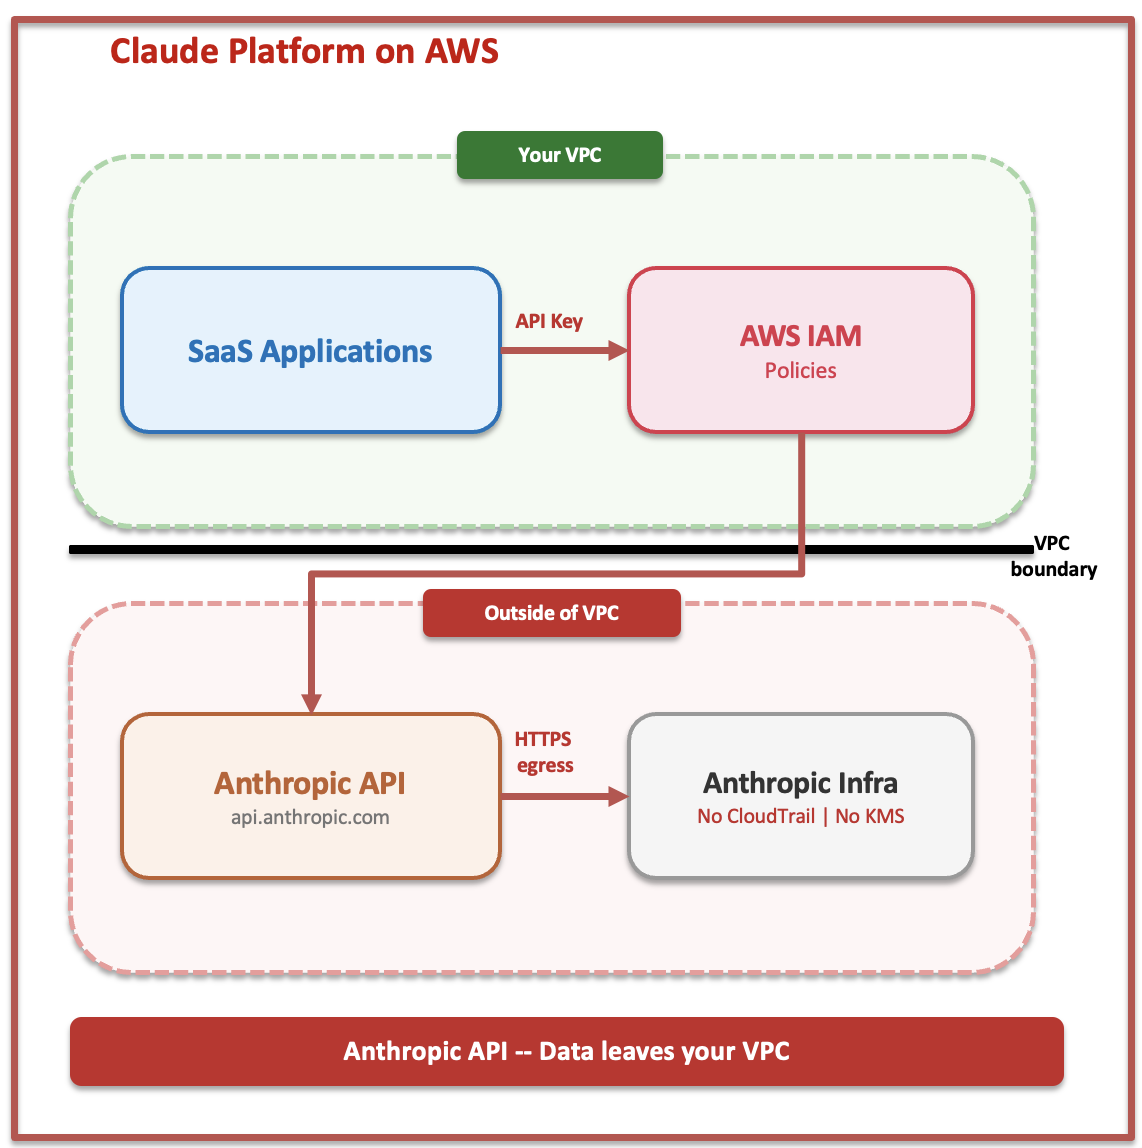

## Install dependencies

Runs once per environment. Skip if you've already installed `requirements.txt` in your venv.

In [ ]:
%pip install -q anthropic python-dotenv Pillow

## 0. Setup

### Authentication options

Claude Platform on AWS supports three authentication methods:

| Method | Credential | Lifetime | Recommended for |
|---|---|---|---|
| **Short-term API key** | `aws-external-anthropic-api-key-...` | 12 hours | Notebooks, quick prototyping, demos |
| **Long-term API key** | `aws-external-anthropic-api-key-...` | Until revoked | CI/CD pipelines, service accounts with limited blast radius |
| **IAM credentials (SigV4)** | AWS access key + secret + session token | Temporary (STS) | Production apps, per-user identity, audit trails |

**Short-term keys** are issued from the CP-on-AWS console and expire every 12 hours. Great for development — no infrastructure setup required.

**Long-term keys** are also issued from the console but don't expire automatically. Use these for automated systems where you can't rotate every 12 hours, but treat them like any long-lived secret (store in Secrets Manager, restrict access).

**IAM credentials (SigV4)** are the production-grade option. You federate your IdP (Okta, Auth0, Entra ID) into AWS IAM Identity Center, and users authenticate with temporary STS credentials. This gives you per-user CloudTrail attribution, automatic credential refresh, and centralized access control via permission sets. See **Chapter 11 of the Advanced notebook (Part 2)** for the full setup.

This notebook uses a **short-term API key** for simplicity.

---

### Credentials

Credentials live in a local `.env` file so you don't paste secrets into the notebook. Copy `.env.example` to `.env` and fill in three values:

```env
ANTHROPIC_AWS_API_KEY=aws-external-anthropic-api-key-...
ANTHROPIC_AWS_WORKSPACE_ID=wrkspc_...
AWS_REGION=us-east-2
CLAUDE_MODEL=claude-sonnet-4-6
```

The short-term API key is issued from the CP-on-AWS console and expires every 12 hours. Rotate as needed.

If you'd rather skip the `.env` dance, paste the values into the fallback block below directly.

In [ ]:
import os
from dotenv import load_dotenv
from anthropic import AnthropicAWS

load_dotenv()  # no-op if .env is missing

# ── Fallback: if you don't want a .env, paste values here ──────────────
# KEY       = "aws-external-anthropic-api-key-..."
# WORKSPACE = "wrkspc_..."
# REGION    = "us-east-2"
# MODEL     = "claude-sonnet-4-6"
# ──────────────────────────────────────────────────────────────────────

KEY       = os.environ.get("ANTHROPIC_AWS_API_KEY")
WORKSPACE = os.environ.get("ANTHROPIC_AWS_WORKSPACE_ID")
REGION    = os.environ.get("AWS_REGION", "us-east-2")
MODEL     = os.environ.get("CLAUDE_MODEL", "claude-sonnet-4-6")

missing = [name for name, val in
           [("ANTHROPIC_AWS_API_KEY", KEY), ("ANTHROPIC_AWS_WORKSPACE_ID", WORKSPACE)]
           if not val]
if missing:
    raise RuntimeError(
        f"Missing credentials: {', '.join(missing)}. "
        "Add them to a .env file next to this notebook, or paste into the fallback block above and re-run this cell."
    )

# One client object drives every chapter.
# AnthropicAWS handles the CP-on-AWS endpoint, bearer auth,
# workspace header, and retries for you.
client = AnthropicAWS(
    api_key=KEY,
    aws_region=REGION,
    workspace_id=WORKSPACE,
    timeout=60.0,
    max_retries=3,
)

KEY       = os.environ.get("ANTHROPIC_AWS_API_KEY")
WORKSPACE = os.environ.get("ANTHROPIC_AWS_WORKSPACE_ID")
REGION    = os.environ.get("AWS_REGION", "us-east-2")
MODEL     = os.environ.get("CLAUDE_MODEL", "claude-sonnet-4-6")

missing = [name for name, val in
           [("ANTHROPIC_AWS_API_KEY", KEY), ("ANTHROPIC_AWS_WORKSPACE_ID", WORKSPACE)]
           if not val]
if missing:
    raise RuntimeError(
        f"Missing credentials: {', '.join(missing)}. "
        "Add them to a .env file next to this notebook, or paste into the fallback block above and re-run this cell."
    )

# One client object drives every chapter.
# AnthropicAWS handles the CP-on-AWS endpoint, bearer auth,
# workspace header, and retries for you.
client = AnthropicAWS(
    api_key=KEY,
    aws_region=REGION,
    workspace_id=WORKSPACE,
    timeout=60.0,
    max_retries=3,
)

print(f"Region:    {REGION}")
print(f"Workspace: {WORKSPACE}")
print(f"Model:     {MODEL}")


## Chapter 1 — Hello Claude

Acme's CEO wants a proof of life before approving the project. Send one message, get one response. If this works, the account is configured.

The API primitive is **Messages**. It's stateless — you always send the full conversation history each time. The output is a list of content blocks (text, tool calls, images, etc.).

In [ ]:
msg = client.messages.create(
    model=MODEL,
    max_tokens=200,
    messages=[{
        "role": "user",
        "content": "Introduce yourself to the Acme Parts Co. engineering team in two sentences.",
    }],
)

print("model:       ", msg.model)
print("stop_reason: ", msg.stop_reason)
print("input tokens:", msg.usage.input_tokens)
print("output tokens:", msg.usage.output_tokens)
print()
for block in msg.content:
    if block.type == "text":
        print(block.text)

Which models are available to you? Every Claude Platform workspace exposes its catalog through `/v1/models`.

In [ ]:
for m in client.models.list().data:
    caps = m.capabilities.model_dump() if hasattr(m, "capabilities") else {}
    flags = ",".join(k for k in ["thinking", "code_execution", "citations", "image_input", "pdf_input"] if caps.get(k, {}).get("supported"))
    print(f"  {m.id:35s}  {m.display_name:25s}  {flags}")

## Chapter 2 — Migrating to Claude Platform on AWS

You might be arriving here from one of two places: **Amazon Bedrock** (using Converse or InvokeModel) or the **native Anthropic API** (`api.anthropic.com`). Acme's CTO wants to know what changes in each case.

Short answer: **very little.** Claude Platform on AWS keeps Anthropic's canonical API shape *and* swaps in AWS auth + billing.

### Option A — Amazon Bedrock Converse (`boto3`)

```python
import boto3

bedrock = boto3.client("bedrock-runtime", region_name="us-east-1")

resp = bedrock.converse(
    modelId="anthropic.claude-sonnet-4-20250514-v1:0",
    messages=[{"role": "user",
               "content": [{"text": "Hello, Claude!"}]}],
    inferenceConfig={"maxTokens": 200},
)
text = resp["output"]["message"]["content"][0]["text"]
```

Expected output:
```
Hello! Happy to help. How can I assist you today?
```

### Option B — Native Anthropic API (`anthropic.Anthropic`)

```python
from anthropic import Anthropic

client = Anthropic(api_key="sk-ant-...")  # Anthropic-issued key

msg = client.messages.create(
    model="claude-sonnet-4-6",
    max_tokens=200,
    messages=[{"role": "user", "content": "Hello, Claude!"}],
)
text = msg.content[0].text
```

Expected output:
```
Hello! How can I help you today?
```

### Option C — Claude Platform on AWS (this notebook)

```python
from anthropic import AnthropicAWS

client = AnthropicAWS(
    api_key=KEY,          # AWS-signed bearer token from your Claude Platform workspace
    aws_region="us-east-2",
    workspace_id=WORKSPACE,
)

msg = client.messages.create(
    model="claude-sonnet-4-6",
    max_tokens=200,
    messages=[{"role": "user", "content": "Hello, Claude!"}],
)
text = msg.content[0].text
```

### Migration at a glance

| | Bedrock Converse | Native Anthropic API | Claude Platform on AWS |
|---|---|---|---|
| **SDK** | `boto3` | `anthropic` (`Anthropic`) | `anthropic` (`AnthropicAWS`) |
| **Auth** | AWS SigV4 | Anthropic-issued API key (`sk-ant-...`) | AWS-signed bearer token + workspace id; also supports **IAM SigV4** for production (see [Part 2, Ch. 11](claude-platform-on-aws-getting-started-02.ipynb)) |
| **Message shape** | AWS-normalized (`content: [{text: ...}]`) | Anthropic canonical (`content: "..."` or blocks) | **Same as Anthropic canonical** |
| **Image content** | `{"image": {"format": "png", "source": {"bytes": ...}}}` | `{"type": "image", "source": {"type": "base64", ...}}` | **Same as native** |
| **Feature surface** | Bedrock feature set (Guardrails, Knowledge Bases, reserved capacity) | Full Anthropic feature set | **Full Anthropic feature set** |
| **Server tools** (web_search, code_execution, memory, computer_use) | ❌ | ✅ | ✅ |
| **Billing** | AWS bill line: Bedrock | Anthropic invoice | AWS bill line: Claude Platform on AWS |
| **Data residency** | In-region, AWS-managed | Anthropic-operated | Anthropic-operated; inference geo not selectable |

### What actually changes in code

**From native Anthropic API → Claude Platform on AWS**

Essentially a client swap. Replace `Anthropic(api_key=...)` with `AnthropicAWS(api_key=..., aws_region=..., workspace_id=...)`. Every `.messages.create`, `.messages.stream`, `.beta.messages.create`, and tool schema stays identical. This is the cheapest migration of the three.

**From Bedrock Converse → Claude Platform on AWS**

Swap `boto3.client('bedrock-runtime')` for `AnthropicAWS(...)`. The message content shape changes from Bedrock-normalized to Anthropic canonical — text is a plain string or a list of typed blocks, images use `{'type': 'image', 'source': {...}}` instead of `{'image': {...}}`. Your AWS IAM moves from `bedrock:InvokeModel` permissions to a subscribe-and-use flow in AWS Marketplace.

### When to choose which

- **Bedrock Converse** — strict regional residency, AWS-managed Guardrails, Bedrock Knowledge Bases, reserved capacity tiers.
- **Native Anthropic API** — you want Anthropic's full feature set and are fine with Anthropic billing and an Anthropic-issued key.
- **Claude Platform on AWS** — you want Anthropic's full feature set (agentic tools, extended thinking, beta features) **with AWS auth and billing**. This is the best of both worlds for AWS-native organizations.

These paths are complementary — many teams run Bedrock for regulated workloads and Claude Platform on AWS for developer productivity in the same account.

> The rest of this notebook uses Claude Platform on AWS exclusively. The Bedrock and native snippets above are shown for comparison and aren't executed; uncomment them in your own environment if you want to run all three side by side.

## Chapter 3 — Vision: seeing a damaged part

A Acme customer emails a photo of a damaged shipment. Your support bot needs to *look* at the image and describe what it sees so a human agent can triage the return.

Claude's Messages API accepts images alongside text in the same `content` array. Supported formats: JPEG, PNG, GIF, WEBP.

We've generated a synthetic photo at `assets/damaged_part.png` — a cardboard box with a bearing inside, a visible crack, and a red arrow annotation. Let's show it and then ask Claude about it.

In [ ]:
import base64
from pathlib import Path
from IPython.display import Image as IPyImage, display

img_bytes = Path("assets/damaged_part.png").read_bytes()
print("The customer sent us this photo:")
display(IPyImage(data=img_bytes))

img_b64 = base64.b64encode(img_bytes).decode()

msg = client.messages.create(
    model=MODEL,
    max_tokens=400,
    messages=[{
        "role": "user",
        "content": [
            {"type": "image", "source": {"type": "base64", "media_type": "image/png", "data": img_b64}},
            {"type": "text", "text":
                "You're a Acme Parts Co. support agent. A customer sent this photo with their complaint. "
                "Describe what you see in 2 short paragraphs, then give a one-line triage recommendation."},
        ],
    }],
)

for block in msg.content:
    if block.type == "text":
        print(block.text)
print(f"\n({msg.usage.input_tokens} in / {msg.usage.output_tokens} out tokens)")

> **Migration note on image content**: the shape above (`type: image` + `source: base64`) is Anthropic's canonical format — identical between the native Anthropic API and Claude Platform on AWS. Bedrock Converse uses a different wrapper: `{"image": {"format": "png", "source": {"bytes": ...}}}`. Keep this in mind if you're migrating from Bedrock.

## Chapter 4 — Conversations: building the support bot

Real support isn't one-shot. Customers ask follow-ups. You build multi-turn by appending turns to the `messages` list. Every turn carries a `role` (`user` or `assistant`) and `content`.

A **system prompt** sets the bot's persona and rules for the whole conversation. It's a top-level parameter, not a turn.

In [ ]:
SYSTEM = (
    "You are Acme Bot, the customer-support assistant for Acme Parts Co., a parts distributor. "
    "Be warm, concise, and accurate. If you don't know an answer, say so and offer to hand off to a human. "
    "Never invent order numbers or prices."
)

conversation = []

def turn(user_text: str) -> str:
    conversation.append({"role": "user", "content": user_text})
    resp = client.messages.create(
        model=MODEL, max_tokens=400, system=SYSTEM, messages=conversation,
    )
    # append the assistant turn so the next call has full context
    conversation.append({"role": "assistant", "content": resp.content})
    return next(b.text for b in resp.content if b.type == "text")

print("👤 I want to return a damaged bearing from order PS-48219.")
print("🤖", turn("I want to return a damaged bearing from order PS-48219."))
print()
print("👤 Will you cover the return shipping?")
print("🤖", turn("Will you cover the return shipping?"))

Notice how the bot kept context across turns without you having to re-explain the order. The `conversation` list is now the full history — including the assistant's original content blocks — ready to be saved to a database or passed to the next request.

## Chapter 5 — Streaming: making the bot feel alive

A 2-second pause between the user pressing enter and a wall of text appearing feels clunky. Streaming turns that into tokens-as-they-arrive, Server-Sent Events style. Same API, just use `client.messages.stream(...)` and iterate.

In [ ]:
print("🤖 ", end="", flush=True)
with client.messages.stream(
    model=MODEL,
    max_tokens=300,
    system=SYSTEM,
    messages=[{"role": "user",
               "content": "Write a friendly 4-sentence email confirming the return was approved for order PS-48219."}],
) as stream:
    for chunk in stream.text_stream:
        print(chunk, end="", flush=True)
    final = stream.get_final_message()

print(f"\n\n({final.usage.output_tokens} output tokens)")

## Chapter 6 — Thinking before answering

A customer asks: *"If I buy 47 bearings at $8.50 each with a 12% volume discount and 7.25% sales tax, what's the total?"* That's a multi-step calculation. Claude can think privately before responding — you see the reasoning trace *and* the final answer.

`thinking: {"type": "adaptive"}` lets the model decide how long to think. Use `{"type": "enabled", "budget_tokens": 2048}` when you want a hard budget.

In [ ]:
msg = client.messages.create(
    model="claude-sonnet-4-6",
    max_tokens=2000,
    thinking={"type": "adaptive"},
    messages=[{"role": "user", "content":
        "A customer orders 47 bearings at $8.50 each. We apply a 12% volume discount, then add 7.25% sales tax. "
        "What's the total in USD?"}],
)

for block in msg.content:
    if block.type == "thinking":
        print("🧠 Claude's private reasoning:")
        print(block.thinking)
        print()
    elif block.type == "text":
        print("💬 Answer to customer:")
        print(block.text)
print(f"\n({msg.usage.input_tokens} in / {msg.usage.output_tokens} out)")

## Chapter 7 — Reaching for tools

The support bot needs to actually *look up* order status. You don't want it guessing. That's what **tools** are for: Claude asks your code to run a function and hands you the answer.

You define a tool schema. Claude decides when to call it. Your code runs the function and returns the result. Claude uses the result to answer the customer.

Here's a `get_order_status` tool backed by a tiny fake database.

In [ ]:
# Pretend order database
ORDERS = {
    "PS-48219": {"status": "delivered", "delivered_on": "2026-04-22", "item": "BRG-1050 Bearing", "qty": 1},
    "PS-49003": {"status": "in_transit", "eta": "2026-05-03", "item": "GSK-220 Gasket set", "qty": 4},
    "PS-49117": {"status": "processing", "eta": "2026-05-05", "item": "MTR-880 Motor assembly", "qty": 1},
}

def get_order_status(order_id: str) -> dict:
    return ORDERS.get(order_id, {"error": "order not found"})

tools = [{
    "name": "get_order_status",
    "description": "Look up the current status of a Acme Parts order by its order id.",
    "input_schema": {
        "type": "object",
        "properties": {"order_id": {"type": "string", "description": "e.g. PS-48219"}},
        "required": ["order_id"],
    },
}]

messages = [{"role": "user", "content": "Hi, when will my order PS-49003 arrive?"}]

for turn_idx in range(4):
    resp = client.messages.create(model=MODEL, max_tokens=500, system=SYSTEM, tools=tools, messages=messages)
    print(f"--- turn {turn_idx}  stop={resp.stop_reason} ---")
    tool_results = []
    for block in resp.content:
        if block.type == "text":
            print("💬", block.text)
        elif block.type == "tool_use":
            print(f"🔧 calling {block.name}({block.input})")
            result = get_order_status(**block.input)
            print(f"   → {result}")
            tool_results.append({"type": "tool_result", "tool_use_id": block.id, "content": str(result)})
    messages.append({"role": "assistant", "content": resp.content})
    if resp.stop_reason != "tool_use":
        break
    messages.append({"role": "user", "content": tool_results})

The loop pattern is the core of all tool use:

1. Send messages with `tools` declared
2. If `stop_reason == 'tool_use'`, iterate the response's `tool_use` blocks, run each function, and collect results
3. Append the assistant's response and a `tool_result` user turn, then loop
4. Stop when `stop_reason` is anything else (`end_turn`, `max_tokens`, `stop_sequence`)

## Chapter 8 — Structured outputs: returning data to downstream systems

The support bot can answer customers in prose — but Acme's warehouse system needs *structured data*. When a customer requests a return, the bot should produce a JSON object that feeds directly into the returns API, not a paragraph a human has to parse.

**Structured outputs** constrain Claude's response to a JSON schema you define. The output is guaranteed to match your schema — no parsing failures, no missing fields.

You define the schema in `output_config.format`, and Claude returns valid JSON in `msg.content[0].text`.

In [ ]:
import json as _json

msg = client.messages.create(
    model=MODEL,
    max_tokens=1024,
    messages=[{
        "role": "user",
        "content": (
            "Process this customer request: "
            "'Hi, I'm Mike Chen (mike.chen@acmemfg.com) from account ACME-042. "
            "I need to return the BRG-1050 bearing from order PS-48219 — it arrived cracked. "
            "Please ship a replacement to our Denver warehouse.'"
        ),
    }],
    output_config={
        "format": {
            "type": "json_schema",
            "schema": {
                "type": "object",
                "properties": {
                    "customer_name": {"type": "string"},
                    "customer_email": {"type": "string"},
                    "account_id": {"type": "string"},
                    "order_id": {"type": "string"},
                    "part_number": {"type": "string"},
                    "reason": {
                        "type": "string",
                        "enum": ["damaged", "defective", "wrong_item", "not_needed"]
                    },
                    "action_requested": {
                        "type": "string",
                        "enum": ["refund", "replacement", "credit"]
                    },
                    "ship_to": {"type": "string"},
                    "priority": {
                        "type": "string",
                        "enum": ["standard", "expedited", "urgent"]
                    },
                },
                "required": [
                    "customer_name", "customer_email", "account_id",
                    "order_id", "part_number", "reason", "action_requested"
                ],
                "additionalProperties": False,
            },
        }
    },
)

# The response is guaranteed valid JSON matching our schema
return_request = _json.loads(msg.content[0].text)

print("Structured return request (ready for the warehouse API):\n")
print(_json.dumps(return_request, indent=2))
print(f"\n({msg.usage.input_tokens} in / {msg.usage.output_tokens} out tokens)")

No regex parsing, no "please respond in JSON" prompt hacking — the schema is enforced at the API level. If a field is `required`, it will always be present. If it has an `enum`, the value will always be one of the allowed options.

**When to use structured outputs vs tool use:**

| | Structured outputs | Tool use |
|---|---|---|
| **Use when** | You need Claude's final answer as structured data | You need Claude to *call your code* mid-conversation |
| **Output** | JSON in `msg.content[0].text` | `tool_use` blocks with `input` you execute |
| **Schema enforcement** | Guaranteed valid JSON matching your schema | Tool `input_schema` validated by Claude |
| **Example** | Extract fields from an email, classify a ticket | Look up an order, run a calculation, query a database |

They're complementary — a production bot might use tool use to look up the order, then structured outputs to format the final return-request object.

## Chapter 9 — Wrap-up

You've shipped the foundation of Acme's support bot:

| Chapter | Feature | API surface |
|---|---|---|
| 1 | Messages basics | `client.messages.create` |
| 2 | Migration from Bedrock Converse | comparison |
| 3 | Vision | image content blocks |
| 4 | Multi-turn conversation | `system`, message history |
| 5 | Streaming | `client.messages.stream` |
| 6 | Extended thinking | `thinking={"type": "adaptive"}` |
| 7 | Custom tools | `tools=[...]`, tool-use loop |
| 8 | Structured outputs | `output_config={"format": {"type": "json_schema", ...}}` |

### What's next — the Advanced notebook

The companion **Advanced** notebook picks up where this one leaves off, covering:

- **Files API** — upload spec sheets once, query by `file_id`
- **Citations** — verifiable answers with source pointers
- **Prompt caching** — 90% input cost reduction on multi-turn conversations
- **Token counting** — estimate cost before sending
- **Server tools** — web search, code execution
- **Memory and text editor** — stateful conversations and file manipulation
- **MCP connector** — plug in external tool servers
- **Computer use** — browser automation (beta)
- **Observability** — CloudTrail audit logs and Cost Explorer billing
- **Production auth** — IdP federation via IAM Identity Center

Happy building.